# 06 — Análise textual dos Informes Semanais (trilha textual, P06)

**Projeto Aplicado II — Guilherme Cunha Oliveira (RA 10754621) e Gabriel Lucca Simionato (RA 10751300)**

Consome o corpus produzido por `04_limpeza_informes.ipynb` e segue a seção 6 do *Roteiro Complementar da Entrega 2*: análise simples e rastreável, com frequência de termos e expressões, identificação de localidades e menções associadas à dengue, TF-IDF opcional e revisão manual de uma amostra. Mesma organização em dez seções dos notebooks de limpeza.

## 1. Objetivo

Identificar **temas, localidades, sorotipos e tendências** mencionados nas seções de dengue dos informes, preservando informe e página de origem em toda saída. A análise é complementar: não gera variável de paciente, não valida o modelo de classificação e não soma acumulados de informes sucessivos.

In [1]:
# ============================================================
# 1. OBJETIVO
# ============================================================
ENTRADA_PREVISTA = "db/bases_tratadas/informes/informes_corpus_2025.csv"
SAIDAS_PREVISTAS = ["informes_frequencia_termos.csv", "informes_mencoes.csv", "informes_tfidf_por_informe.csv", "informes_indicadores_citados.csv", "informes_amostra_revisao.csv", "informes_sintese_por_informe.csv"]

## 2. Bibliotecas

pandas para o corpus e as tabelas; `re` e `unicodedata` para as regras textuais; `TfidfVectorizer` do scikit-learn para o TF-IDF; Matplotlib para os gráficos. A lista de *stopwords* do português é mantida no próprio notebook para não depender de download.

In [2]:
# ============================================================
# 2. BIBLIOTECAS
# ============================================================
import re, json, unicodedata, warnings
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
warnings.filterwarnings("ignore"); plt.rcParams.update({"axes.grid": True, "grid.alpha": .3})
pd.set_option("display.width", 160, "display.max_colwidth", 100)
SEED = 42

## 3. Caminhos

In [3]:
# ============================================================
# 3. CAMINHOS
# ============================================================
RAIZ = Path("..").resolve()
TRATADA = RAIZ/"db/bases_tratadas/informes"
FIG = RAIZ/"reports/figuras"; FIG.mkdir(parents=True, exist_ok=True)
ARQ_CORPUS = TRATADA/"informes_corpus_2025.csv"
ARQ_SECOES = TRATADA/"informes_secoes_detectadas.csv"
ARQ_IBGE   = RAIZ/"db/bases_tratadas/ibge/ibge_municipio_2022_tratado.csv"
SAIDA = {n: TRATADA/n for n in SAIDAS_PREVISTAS}
ARQ_LOG = TRATADA/"informes_analise_log.json"
LOG = {"entrada": str(ARQ_CORPUS.relative_to(RAIZ)), "etapas": {}}
print("corpus existe:", ARQ_CORPUS.exists(), "| IBGE tratado existe:", ARQ_IBGE.exists())

corpus existe: True | IBGE tratado existe: True


## 4. Carregamento

O corpus tem uma linha por página. A unidade de análise é a **seção de dengue** de cada informe: usamos `texto_dengue` das páginas marcadas com `secao_dengue = 1`. As páginas de dengue são de dois tipos, marcados na limpeza: **narrativa** (texto da situação epidemiológica, diagrama de controle, mapa de sorotipos e infográfico) e **tabela anexa** (casos, graves e óbitos por UF). Termos, tendências e TF-IDF usam só a narrativa, porque as tabelas repetem as 27 UFs em todo informe; as localidades são contadas nos dois tipos, separadamente. Se um informe não tivesse seção detectada, seu texto limpo inteiro entraria com `fallback_texto_completo = 1`.

In [4]:
# ============================================================
# 4. CARREGAMENTO
# ============================================================
if ARQ_CORPUS.exists():
    corpus = pd.read_csv(ARQ_CORPUS, dtype={"texto_original": str, "texto_limpo": str, "texto_dengue": str}).fillna({"texto_limpo": "", "texto_dengue": ""})
else:
    corpus = pd.DataFrame(columns=["informe","pagina","sem_texto","n_caracteres","texto_original","texto_limpo","secao_dengue","texto_dengue"])
    print(">>> corpus não encontrado: execute 04_limpeza_informes.ipynb com os PDFs em db/bases_brutas/informes/")
paginas = []
for inf, g in corpus.groupby("informe"):
    tem_secao = (g.secao_dengue == 1).any()
    for _, r in g.iterrows():
        txt = r.texto_dengue if tem_secao else r.texto_limpo
        if tem_secao and r.secao_dengue != 1: continue
        tipo = r.tipo_secao_dengue if ("tipo_secao_dengue" in g.columns and isinstance(r.tipo_secao_dengue, str) and r.tipo_secao_dengue) else "narrativa"
        paginas.append({"informe": inf, "pagina": int(r.pagina), "fallback_texto_completo": int(not tem_secao), "tipo": tipo, "texto": txt})
paginas = pd.DataFrame(paginas, columns=["informe","pagina","fallback_texto_completo","tipo","texto"])
narr = paginas[paginas.tipo.str.contains("narrativa")] if len(paginas) else paginas
periodo = corpus.groupby("informe")[["informe_num","se_inicio","se_fim","data_informe"]].first() if "informe_num" in corpus.columns else pd.DataFrame()
if len(periodo): paginas = paginas.merge(periodo, left_on="informe", right_index=True, how="left").sort_values(["informe_num","pagina"]).reset_index(drop=True)
print(f"{corpus.informe.nunique()} informe(s), {len(corpus)} páginas no corpus, {len(paginas)} páginas de dengue: {len(narr)} narrativas/infográfico e {len(paginas)-len(narr)} de tabelas anexas ({int(paginas.fallback_texto_completo.sum()) if len(paginas) else 0} por fallback)")
LOG["etapas"]["carregamento"] = {"informes": int(corpus.informe.nunique()), "paginas_corpus": int(len(corpus)), "paginas_analisadas": int(len(paginas))}

17 informe(s), 343 páginas no corpus, 120 páginas de dengue: 69 narrativas/infográfico e 51 de tabelas anexas (0 por fallback)


## 5. Diagnóstico do corpus

Tamanho do texto por informe, páginas com seção de dengue e uma amostra do início de cada seção, para conferir que a regra de segmentação do notebook 04 pegou o trecho certo.

In [5]:
# ============================================================
# 5. DIAGNÓSTICO
# ============================================================
if len(paginas):
    diag = paginas.groupby("informe").agg(paginas=("pagina","nunique"), palavras=("texto", lambda s: sum(len(t.split()) for t in s)), fallback=("fallback_texto_completo","max"))
    print(diag.to_string())
    print("\nInício da seção de dengue (primeira página analisada) por informe:")
    for inf, g in paginas.groupby("informe", sort=False): print(f"  {inf[:32]}: {g.iloc[0].texto[:150]}…")

                                                                                          paginas  palavras  fallback
informe                                                                                                              
Informe Semanal nº 01 - COE Dengue e outras Arboviroses - SE 1 a 4  - 27 de janeiro.pdf         8      1012         0
Informe Semanal nº 02 - COE Dengue e outras Arboviroses - SE 1 a 8 - 24 de fevereiro.pdf        7       999         0
Informe Semanal nº 03 - COE Dengue e outras Arboviroses - SE 1 a 9 - 08 de março.pdf            7      1026         0
Informe Semanal nº 04 - COE Dengue e outras Arboviroses - SE 1 a 10.pdf                         7      1019         0
Informe Semanal nº 05 - COE Dengue e outras Arboviroses - SE 1 a 11.pdf                         7      1018         0
Informe Semanal nº 06 - COE Dengue e outras Arboviroses - SE 1 a 12.pdf                         7      1015         0
Informe Semanal nº 07 - COE Dengue e outras Arboviroses 

## 6. Regras da análise

- **R1 — Normalização para contagem.** Minúsculas, acentos removidos, apenas letras; *stopwords* do português e termos de estrutura ("figura", "tabela", "fonte") retirados. A normalização serve às contagens; o texto exibido nas menções é o original.
- **R2 — Termos e expressões relevantes.** Dicionário fixo, revisável, em quatro grupos: **sorotipos** (DENV-1 a DENV-4, "sorotipo"), **tendência** (aumento, redução, queda, estabilidade, crescimento, declínio, tendência), **gravidade** (óbito, grave, alarme, internação, letalidade) e **vigilância** (incidência, notificação, confirmado, provável, semana epidemiológica). Cada ocorrência é registrada com informe, página e trecho de contexto.
- **R3 — Localidades.** Candidatas identificadas por correspondência exata (com limites de palavra, sem acentos) com nomes de UF, regiões e municípios do IBGE tratado. Como os informes do COE descrevem o país por UF, um nome que é ao mesmo tempo UF e município ("São Paulo", "Mato Grosso" — que também é município na Paraíba) é classificado como UF, e o número de homônimos fica registrado. Só entram nomes com pelo menos 5 letras, e toda menção vai para a revisão manual com o trecho. Menções em tabelas anexas são contadas à parte.
- **R4 — TF-IDF (opcional).** Um documento por informe (seção de dengue concatenada); `TfidfVectorizer` com as mesmas *stopwords*, unigramas e bigramas, mínimo de 2 documentos; os 10 termos de maior peso por informe destacam o que é relativamente característico de cada semana.
- **R5 — Revisão manual.** Amostra aleatória (semente 42) de 30 menções com o trecho, gravada com uma coluna `revisao` vazia para o grupo preencher (procede / negação / fora de contexto / outra doença).
- **R6 — Indicadores citados no texto.** Da narrativa de cada informe extraímos, por expressões regulares, os números que o próprio texto cita: casos prováveis notificados, coeficiente de incidência, variação em relação a 2024, óbitos confirmados e em investigação, e os sorotipos citados. Cada valor é **acumulado da SE 1 até a SE final do informe** e fica na linha do seu informe, nunca somado a outro.
- **R7 — Limites.** Ausência de menção não indica ausência de casos; a análise não alimenta o modelo nem o valida.

In [6]:
# ============================================================
# 6. REGRAS DA ANÁLISE
# ============================================================
STOP = set('''a à as ao aos o os um uma uns umas de do da dos das em no na nos nas por para com sem sob sobre entre até desde e ou mas que se
não sim mais menos muito muitos muita muitas pouco poucos é são foi foram ser será serão está estão esteve estavam estar há havia ter tem têm tinha
como quando onde qual quais quem cujo cuja este esta estes estas esse essa esses essas aquele aquela isso isto aquilo seu sua seus suas nosso nossa
ele ela eles elas nós eu tu você vocês lhe lhes me te nos já ainda também só apenas mesmo mesma mesmos mesmas outro outra outros outras todo toda todos
todas cada ambos ambas pelo pela pelos pelas num numa nele nela neste nesta nesse nessa deste desta desse dessa dele dela ante após contra durante
perante segundo conforme além dentro fora acima abaixo assim então portanto porém contudo entretanto todavia logo pois porque porquê ano anos dia dias
mês meses vs figura tabela fonte gráfico quadro pág pagina página nº n º'''.split())
ESTRUTURA = {"figura","tabela","fonte","grafico","quadro","boletim","informe","ase","sinan","sinanon","line"}

RE_FONTE = re.compile(r"Fonte:[^.]*\.(?:\s*Dados sujeitos a altera[cç][aã]o\.)?", re.I)      # frases de fonte dos gráficos
RE_GLUED = re.compile(r"\b\d\S{25,}")                                       # notas de rodapé com palavras coladas (ex.: 1Dadosatualizadosem…)
def sem_fonte(t): return RE_GLUED.sub(" ", RE_FONTE.sub(" ", str(t)))
def normalizar(t):
    t = unicodedata.normalize("NFKD", str(t)).encode("ascii", "ignore").decode().lower()
    return re.sub(r"[^a-z\s]", " ", t)
STOP = {normalizar(w).strip() for w in STOP}      # mesma normalização dos tokens (não -> nao, será -> sera)
def tokens(t):
    return [w for w in normalizar(sem_fonte(t)).split() if len(w) > 2 and w not in STOP and w not in ESTRUTURA]

EXPRESSOES = {
 "sorotipo":   r"\b(denv[\s\-]?[1234]|sorotipos?)\b",
 "tendencia":  r"\b(aumento|aumentou|elevacao|reducao|reduziu|queda|caiu|estabilidade|estavel|crescimento|cresceu|declinio|tendencia)\b",
 "gravidade":  r"\b(obitos?|graves?|alarme|internac(ao|oes)|letalidade)\b",
 "vigilancia": r"\b(incidencia|notificac(ao|oes)|notificados?|confirmados?|provaveis|prov[aá]vel|semanas? epidemiologicas?)\b",
}
CONTEXTO = 70   # caracteres de cada lado do trecho

def mencoes_por_regex(df, nome, padrao):
    out = []
    for _, r in df.iterrows():
        norm = normalizar(r.texto)
        for m in re.finditer(padrao, norm):
            out.append({"informe": r.informe, "pagina": r.pagina, "grupo": nome, "termo": m.group(0),
                        "trecho": r.texto[max(0, m.start()-CONTEXTO): m.end()+CONTEXTO].replace("\n", " ")})
    return out

In [7]:
# R3 — localidades a partir do IBGE tratado
if ARQ_IBGE.exists():
    ibge = pd.read_csv(ARQ_IBGE, dtype=str)
    locais = {}
    for uf in ibge.uf.unique(): locais.setdefault(normalizar(uf).strip(), []).append(("uf", uf, None))          # UF e região têm prioridade:
    for rg in ibge.regiao.unique(): locais.setdefault(normalizar(rg).strip(), []).append(("regiao", rg, None))  # nos informes federais o nível é estadual
    for _, r in ibge.iterrows():
        n = normalizar(r.nome_municipio).strip()
        if len(n) >= 5: locais.setdefault(n, []).append(("municipio", f"{r.nome_municipio} ({r.uf})", r.cod_municipio))
    print("nomes de localidade no dicionário:", len(locais), "(municípios ≥ 5 letras, UFs e regiões)")
else:
    locais = {}; print("IBGE tratado ausente: execute 03_limpeza_ibge.ipynb para identificar localidades")
padrao_locais = re.compile(r"\b(" + "|".join(sorted((re.escape(k) for k in locais), key=len, reverse=True)) + r")\b") if locais else None

nomes de localidade no dicionário: 5226 (municípios ≥ 5 letras, UFs e regiões)


## 7. Aplicação

In [8]:
# ============================================================
# 7. APLICAÇÃO
# ============================================================
freq_geral, freq_inf, mencoes = Counter(), {}, []
for inf, g in narr.groupby("informe"):
    c = Counter(w for t in g.texto for w in tokens(t)); freq_inf[inf] = c; freq_geral.update(c)
for nome, padrao in EXPRESSOES.items(): mencoes += [dict(m, tipo_pagina="narrativa") for m in mencoes_por_regex(narr, nome, padrao)]
if padrao_locais is not None:
    for _, r in paginas.iterrows():
        norm = normalizar(sem_fonte(r.texto))
        for m in padrao_locais.finditer(norm):
            tipo, nome, cod = locais[m.group(0)][0]
            mencoes.append({"informe": r.informe, "pagina": r.pagina, "grupo": f"localidade_{tipo}", "termo": nome, "tipo_pagina": r.tipo,
                            "trecho": r.texto[max(0, m.start()-CONTEXTO): m.end()+CONTEXTO].replace("\n", " "), "cod_municipio": cod,
                            "homonimos": len(locais[m.group(0)])})
mencoes = pd.DataFrame(mencoes, columns=["informe","pagina","grupo","termo","tipo_pagina","trecho","cod_municipio","homonimos"])
freq_tab = pd.DataFrame(freq_geral.most_common(40), columns=["termo","frequencia"])
print("termos mais frequentes na narrativa de dengue (após stopwords):"); print(freq_tab.head(25).to_string(index=False))
print("\nmenções por grupo e tipo de página:"); print(pd.crosstab(mencoes.grupo, mencoes.tipo_pagina).to_string() if len(mencoes) else "nenhuma")
print("\nUFs mais citadas na narrativa:"); print(mencoes[(mencoes.grupo == "localidade_uf") & (mencoes.tipo_pagina == "narrativa")].termo.value_counts().head(12).to_string() if len(mencoes) else "")

termos mais frequentes na narrativa de dengue (após stopwords):
       termo  frequencia
       casos         156
        denv         116
      dengue         104
      obitos          84
  incidencia          81
   provaveis          55
     periodo          54
     sudeste          51
 coeficiente          47
      numero          46
     maiores          46
         sul          44
     regioes          35
       virus          35
         mil          34
      centro          34
       oeste          34
       paulo          34
      graves          34
investigacao          34
   sorotipos          34
    diagrama          34
    controle          34
  apresentam          29
        mato          26

menções por grupo e tipo de página:
tipo_pagina        narrativa  tabela
grupo                               
gravidade                152       0
localidade_regiao        119     255
localidade_uf            129    1377
sorotipo                  34       0
tendencia                 6

In [9]:
# R4 — TF-IDF opcional, um documento por informe
docs = narr.groupby("informe").texto.apply(lambda s: " ".join(normalizar(sem_fonte(t)) for t in s))
tfidf_top = pd.DataFrame(columns=["informe","termo","peso"])
if len(docs) >= 2:
    vec = TfidfVectorizer(stop_words=sorted(STOP | ESTRUTURA), ngram_range=(1, 2), min_df=2, max_df=0.8, token_pattern=r"(?u)\b[a-z]{3,}\b")   # max_df exclui o que aparece em >80% dos informes
    X = vec.fit_transform(docs); termos = vec.get_feature_names_out()
    linhas = []
    for i, inf in enumerate(docs.index):
        row = X[i].toarray().ravel(); top = row.argsort()[::-1][:10]
        linhas += [{"informe": inf, "termo": termos[j], "peso": round(float(row[j]), 4)} for j in top if row[j] > 0]
    tfidf_top = pd.DataFrame(linhas)
    print("termos mais característicos por informe (TF-IDF):"); print(tfidf_top.groupby("informe").termo.apply(lambda s: ", ".join(s)).to_string())
else:
    print("TF-IDF requer ao menos 2 informes")

termos mais característicos por informe (TF-IDF):
informe
Informe Semanal nº 01 - COE Dengue e outras Arboviroses - SE 1 a 4  - 27 de janeiro.pdf     tres sorotipos, trimestre numero, circulacao tres, limites, limites canal, encontra limites, fed...
Informe Semanal nº 02 - COE Dengue e outras Arboviroses - SE 1 a 8 - 24 de fevereiro.pdf    tres sorotipos, trimestre numero, circulacao tres, limites, limites canal, encontra limites, fed...
Informe Semanal nº 03 - COE Dengue e outras Arboviroses - SE 1 a 9 - 08 de março.pdf        vacinal numero, paciente deteccoes, paciente, amostras paciente, amostras, vacinados virus, dete...
Informe Semanal nº 04 - COE Dengue e outras Arboviroses - SE 1 a 10.pdf                     vacinal numero, paciente deteccoes, paciente, amostras paciente, amostras, vacinados virus, dete...
Informe Semanal nº 05 - COE Dengue e outras Arboviroses - SE 1 a 11.pdf                     vacinal coeficiente, paciente deteccoes, paciente, amostras paciente, amostras, va

In [10]:
# R6 — indicadores citados na narrativa de cada informe (acumulados SE 1 -> SE final; não somar entre informes)
RE_IND = {
 "casos_provaveis":      r"foram notificados\s+([\d\.]+)\s+casos prov[aá]veis de\s+dengue",
 "incidencia_100mil":    r"coeficiente de incid[eê]ncia de\s+([\d\.,]+)\s+casos\s*/\s*100",
 "variacao_vs_2024_pct": r"(redu[cç][aã]o|aumento) de\s+([\d\.,]+)\s*%\s+no n[uú]mero de casos prov[aá]veis",
 "obitos_confirmados":   r"foram confirmados\s+([\d\.]+)\s+[oó]bitos",
 "obitos_investigacao":  r"([\d\.]+)\s+est[aã]o em investiga[cç][aã]o",
 "tendencia_nowcasting": r"(tend[eê]ncia (?:de |à )(?:alta|queda|estabilidade|redu[cç][aã]o)[^.]*|estimativa (?:por )?nowcasting[^.]*)",
}
def num_br(x): return float(str(x).replace(".", "").replace(",", "."))
indic = []
for inf, g in narr.groupby("informe", sort=False):
    texto = " ".join(g.texto); linha = {"informe": inf}
    for k, pat in RE_IND.items():
        m = re.search(pat, texto, re.I)
        if not m: linha[k] = np.nan; continue
        if k == "variacao_vs_2024_pct": linha[k] = (-1 if m.group(1).lower().startswith("redu") else 1) * num_br(m.group(2))
        elif k == "tendencia_nowcasting": linha[k] = m.group(1)[:110]
        else: linha[k] = num_br(m.group(1))
    soro = sorted(set(x.upper().replace(" ", "").replace("DENV", "DENV-").replace("--", "-") for x in re.findall(r"denv[\s\-]?[1234]", texto, re.I)))
    linha["sorotipos_citados"] = ", ".join(soro)
    pred = re.search(r"predomin[aâ]ncia d[oe]\s+(denv[\s\-]?\d)", texto, re.I); linha["sorotipo_predominante"] = pred.group(1).upper().replace(" ", "-") if pred else ""
    indic.append(linha)
indic = pd.DataFrame(indic)
if len(periodo) and len(indic): indic = indic.merge(periodo, left_on="informe", right_index=True, how="left").sort_values("informe_num")
indic.drop(columns=["informe"], errors="ignore")

,casos_provaveis,incidencia_100mil,variacao_vs_2024_pct,obitos_confirmados,obitos_investigacao,tendencia_nowcasting,sorotipos_citados,sorotipo_predominante,informe_num,se_inicio,se_fim,data_informe
0,139241.0,68.6,-57.9,21.0,160.0,estimativa nowcasting2 indica tendência de alta no número de casos,"DENV-1, DENV-2, DENV-3",,1,1,4,2025-01-27
1,401408.0,197.7,-68.2,160.0,377.0,estimativa nowcasting indica tendência de alta no número de casos acima do limite esperado,"DENV-1, DENV-2, DENV-3",,2,1,8,2025-02-24
2,480715.0,236.7,-70.0,203.0,458.0,"estimativa nowcasting indica tendência de alta no número de casos, acima do limite esperado","DENV-1, DENV-2, DENV-3, DENV-4",,3,1,9,2025-03-08
3,533829.0,262.9,-72.9,243.0,520.0,"estimativa nowcasting indica tendência de alta no número de casos, acima do limite esperado","DENV-1, DENV-2, DENV-3, DENV-4",,4,1,10,2025-03-10
4,620702.0,305.7,-73.8,304.0,632.0,"estimativa nowcasting indica tendência de alta no número de casos, acima do limite esperado","DENV-1, DENV-2, DENV-3, DENV-4",,5,1,11,2025-03-17
5,709634.0,349.5,-74.7,377.0,684.0,"estimativa nowcasting indica tendência de alta no número de casos, acima do limite esperado","DENV-1, DENV-2, DENV-3, DENV-4",,6,1,12,2025-03-24
6,807778.0,397.8,-74.6,451.0,704.0,"estimativa nowcasting indica tendência de alta no número de casos, acima do limite esperado","DENV-1, DENV-2, DENV-3, DENV-4",,7,1,13,2025-03-31
7,896680.0,441.6,-75.1,536.0,727.0,"estimativa nowcasting indica tendência de alta no número de casos, acima do limite esperado para...","DENV-1, DENV-2, DENV-3, DENV-4",,8,1,14,2025-04-07
8,983138.0,484.2,-75.5,622.0,741.0,"estimativa por nowcasting indica acima do limite superior esperado para o período atual, embora ...","DENV-1, DENV-2, DENV-3, DENV-4",DENV-2,9,1,15,2025-04-14
9,1051311.0,517.7,-76.1,703.0,714.0,tendência de queda e retorno ao canal endêmico,"DENV-1, DENV-2, DENV-3, DENV-4",DENV-2,10,1,16,2025-04-22


Os valores acima são os que o próprio texto de cada informe declara para o período acumulado (SE 1 até a SE final daquele informe). Eles descrevem a trajetória da temporada de 2025 tal como o COE a relatou semana a semana e servem para contextualizar os resultados tabulares — não são somados, e não substituem o SINAN.

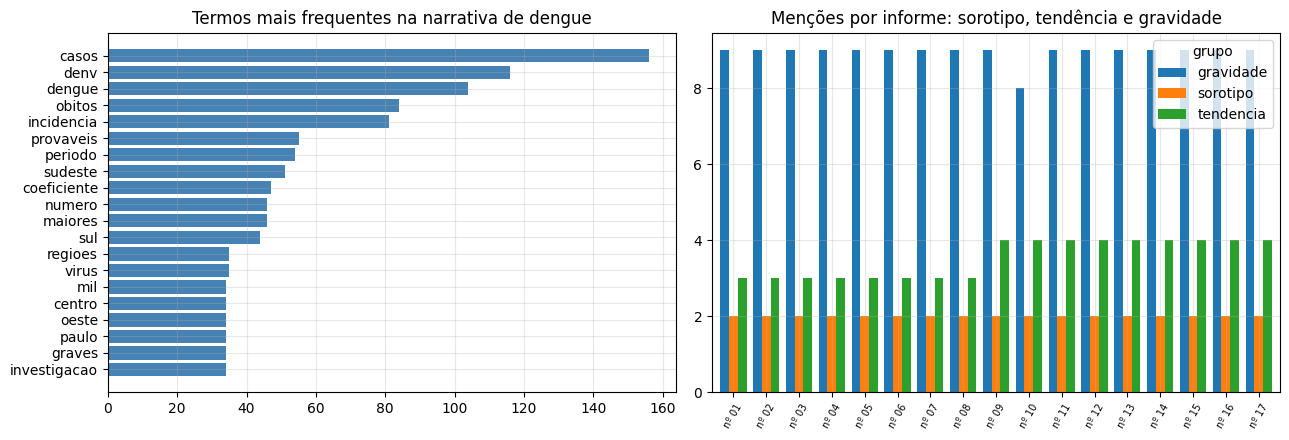

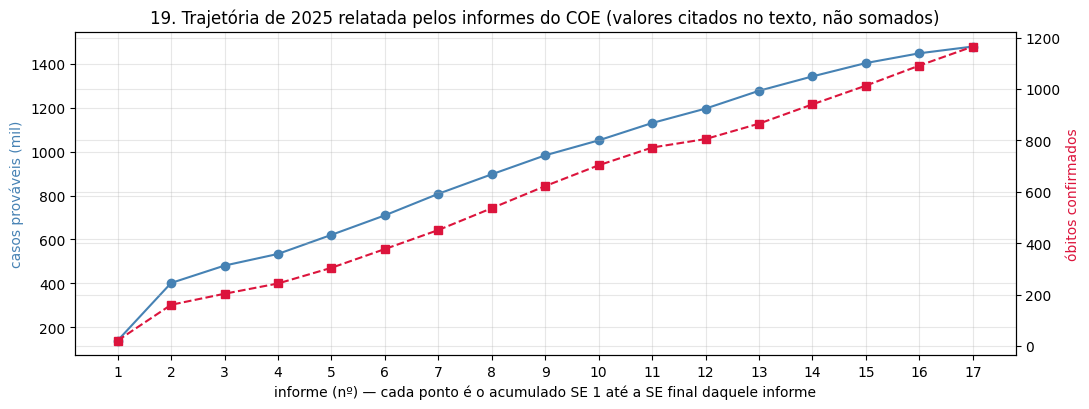

In [11]:
if len(mencoes):
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
    ax[0].barh(freq_tab.termo.head(20)[::-1], freq_tab.frequencia.head(20)[::-1], color="steelblue"); ax[0].set_title("Termos mais frequentes na narrativa de dengue")
    g = mencoes[mencoes.grupo.isin(["sorotipo","tendencia","gravidade"]) & (mencoes.tipo_pagina == "narrativa")].groupby(["informe","grupo"]).size().unstack(fill_value=0)
    if len(periodo): g.index = g.index.map(lambda i: f"nº {int(periodo.loc[i, 'informe_num']):02d}"); g = g.sort_index()
    g.plot(kind="bar", ax=ax[1], width=.8); ax[1].set_title("Menções por informe: sorotipo, tendência e gravidade"); ax[1].set_xlabel(""); ax[1].tick_params(axis="x", rotation=60, labelsize=7)
    plt.tight_layout(); plt.savefig(FIG/"18_informes_termos_mencoes.png", dpi=120); plt.show()
if len(indic) and indic.casos_provaveis.notna().any():
    fig, ax1 = plt.subplots(figsize=(11, 4.2)); x = indic.informe_num.astype(int)
    ax1.plot(x, indic.casos_provaveis/1e3, "o-", color="steelblue", label="casos prováveis acumulados (mil)"); ax1.set_ylabel("casos prováveis (mil)", color="steelblue"); ax1.set_xlabel("informe (nº) — cada ponto é o acumulado SE 1 até a SE final daquele informe")
    ax2 = ax1.twinx(); ax2.plot(x, indic.obitos_confirmados, "s--", color="crimson", label="óbitos confirmados"); ax2.set_ylabel("óbitos confirmados", color="crimson")
    ax1.set_xticks(x); ax1.set_title("19. Trajetória de 2025 relatada pelos informes do COE (valores citados no texto, não somados)")
    plt.tight_layout(); plt.savefig(FIG/"19_informes_trajetoria_citada.png", dpi=120); plt.show()

## 8. Revisão manual (R5)

Uma amostra aleatória de menções, com o trecho de contexto, para o grupo classificar. A coluna `revisao` fica vazia de propósito; depois de preenchida, as contagens da seção 7 devem ser relidas descontando negações e trechos fora de contexto.

In [12]:
# ============================================================
# 8. REVISÃO MANUAL
# ============================================================
amostra = mencoes.sample(min(30, len(mencoes)), random_state=SEED).sort_values(["informe","pagina"]) if len(mencoes) else mencoes.copy()
amostra["revisao"] = ""; amostra["observacao"] = ""
amostra[["informe","pagina","grupo","termo","trecho","revisao","observacao"]].head(15)

,informe,pagina,grupo,termo,trecho,revisao,observacao
100,Informe Semanal nº 01 - COE Dengue e outras Arboviroses - SE 1 a 4 - 27 de janeiro.pdf,7,gravidade,graves,41 Casos prováveis Óbitos em 160 de casos investigação no mesmo Casos graves e com 1.082 período...,,
432,Informe Semanal nº 01 - COE Dengue e outras Arboviroses - SE 1 a 4 - 27 de janeiro.pdf,16,localidade_uf,Roraima,"28 32,2 8,1 Acre 2.020 2.705 243,4 325,9 Amazonas 1.970 682 50,0 17,3 Roraima 33 48 5,2 7,5 Pará...",,
472,Informe Semanal nº 01 - COE Dengue e outras Arboviroses - SE 1 a 4 - 27 de janeiro.pdf,17,localidade_uf,Rio Grande do Norte,5 1 Nordeste 6 3 156 26 Maranhão 0 1 8 0 Piauí 0 0 11 1 Ceará 0 0 7 1 Rio Grande do Norte 1 0 4 ...,,
111,Informe Semanal nº 02 - COE Dengue e outras Arboviroses - SE 1 a 8 - 24 de fevereiro.pdf,7,gravidade,letalidade,"ão no mesmo Casos graves e com 4.014 período de sinais de alarme 4,0% Letalidade1 2024",,
555,Informe Semanal nº 02 - COE Dengue e outras Arboviroses - SE 1 a 8 - 24 de fevereiro.pdf,16,localidade_uf,Rio de Janeiro,"373.362 45.696 1.817,8 222,5 Espírito Santo 20.939 7.269 546,2 189,6 Rio de Janeiro 76.358 8.35...",,
788,Informe Semanal nº 04 - COE Dengue e outras Arboviroses - SE 1 a 10.pdf,15,localidade_uf,Piauí,2 56 4 Tocantins 2 0 25 2 Nordeste 91 13 1.501 187 Maranhão 6 1 71 7 Piauí 5 4 102 24 Ceará 1 0...,,
900,Informe Semanal nº 05 - COE Dengue e outras Arboviroses - SE 1 a 11.pdf,15,localidade_uf,Sergipe,Norte 5 0 35 10 Paraíba 4 0 49 5 Pernambuco 3 1 22 6 Alagoas 3 2 37 8 Sergipe 3 1 18 7 Bahia 86 ...,,
303,Informe Semanal nº 06 - COE Dengue e outras Arboviroses - SE 1 a 12.pdf,3,vigilancia,incidencia,Diagrama de controle Coeficiente de Incidência e óbitos Fonte: Sinan On-line (banco de dados atu...,,
1159,Informe Semanal nº 07 - COE Dengue e outras Arboviroses - SE 1 a 13.pdf,16,localidade_regiao,Centro-Oeste,"6 Santa Catarina 137 2 4,9 0,0 0 4 Rio Grande do Sul 98 1 9,0 0,9 1 3 Centro-Oeste 585 34 4,5 2,...",,
321,Informe Semanal nº 08 - COE Dengue e outras Arboviroses - SE 1 a 13.pdf,2,vigilancia,confirmados,Centro-Oeste e Sul. Os óbitos concentram-se na região Sudeste. Foram confirmados 536 óbitos no ...,,


## 9. Exportação

Todas as saídas carregam `informe` e `pagina`; as menções trazem também o trecho de contexto e, para municípios, o código IBGE e o número de homônimos.

In [13]:
# ============================================================
# 9. EXPORTAÇÃO
# ============================================================
if len(paginas):
    pd.DataFrame([{"informe": inf, "termo": t, "frequencia": n} for inf, c in freq_inf.items() for t, n in c.most_common(50)]).to_csv(SAIDA["informes_frequencia_termos.csv"], index=False)
    mencoes.to_csv(SAIDA["informes_mencoes.csv"], index=False)
    tfidf_top.to_csv(SAIDA["informes_tfidf_por_informe.csv"], index=False)
    amostra.to_csv(SAIDA["informes_amostra_revisao.csv"], index=False)
    sintese = paginas.groupby("informe").agg(paginas_analisadas=("pagina","nunique"), fallback=("fallback_texto_completo","max"), palavras=("texto", lambda s: sum(len(t.split()) for t in s))).reset_index()
    if len(periodo): sintese = sintese.merge(periodo, left_on="informe", right_index=True, how="left").sort_values("informe_num")
    indic.to_csv(SAIDA["informes_indicadores_citados.csv"], index=False)
    for grp in ["sorotipo","tendencia","gravidade","vigilancia","localidade_uf","localidade_regiao","localidade_municipio"]:
        sub = mencoes[(mencoes.grupo == grp) & (mencoes.tipo_pagina == "narrativa")]
        sintese[grp] = sintese.informe.map(sub.groupby("informe").size()).fillna(0).astype(int)
        sintese[grp + "_termos"] = sintese.informe.map(sub.groupby("informe").termo.apply(lambda s: ", ".join(pd.Series(s).value_counts().head(5).index))).fillna("")
    sintese["top_termos"] = sintese.informe.map({inf: ", ".join(t for t, _ in c.most_common(8)) for inf, c in freq_inf.items()})
    sintese.to_csv(SAIDA["informes_sintese_por_informe.csv"], index=False)
    LOG["etapas"]["exportacao"] = {k: str(v.relative_to(RAIZ)) for k, v in SAIDA.items()}; print("saídas gravadas em", TRATADA.relative_to(RAIZ))
    display(sintese)
else:
    LOG["etapas"]["exportacao"] = "não executada: corpus vazio"; print("nada gravado")
LOG["executado_em"] = pd.Timestamp.now().strftime("%Y-%m-%d %H:%M")
ARQ_LOG.write_text(json.dumps(LOG, indent=2, ensure_ascii=False, default=str), encoding="utf-8")

saídas gravadas em db/bases_tratadas/informes


,informe,paginas_analisadas,fallback,palavras,informe_num,se_inicio,se_fim,data_informe,sorotipo,sorotipo_termos,...,gravidade_termos,vigilancia,vigilancia_termos,localidade_uf,localidade_uf_termos,localidade_regiao,localidade_regiao_termos,localidade_municipio,localidade_municipio_termos,top_termos
0,Informe Semanal nº 01 - COE Dengue e outras Arboviroses - SE 1 a 4 - 27 de janeiro.pdf,8,0,1012,1,1,4,2025-01-27,2,sorotipos,...,"obitos, graves, alarme, letalidade",10,"provaveis, incidencia, notificados, confirmados",5,"São Paulo, Acre, Mato Grosso, Pará",7,"Sudeste, Centro-Oeste, Sul",0,,"casos, dengue, obitos, provaveis, incidencia, numero, denv, periodo"
1,Informe Semanal nº 02 - COE Dengue e outras Arboviroses - SE 1 a 8 - 24 de fevereiro.pdf,7,0,999,2,1,8,2025-02-24,2,sorotipos,...,"obitos, graves, alarme, letalidade",10,"provaveis, incidencia, notificados, confirmados",3,"Acre, São Paulo, Mato Grosso",7,"Sudeste, Centro-Oeste, Sul",0,,"casos, dengue, obitos, provaveis, incidencia, numero, denv, periodo"
2,Informe Semanal nº 03 - COE Dengue e outras Arboviroses - SE 1 a 9 - 08 de março.pdf,7,0,1026,3,1,9,2025-03-08,2,sorotipos,...,"obitos, graves, alarme, letalidade",10,"provaveis, incidencia, notificados, confirmados",3,"Acre, São Paulo, Mato Grosso",7,"Sudeste, Centro-Oeste, Sul",0,,"casos, dengue, denv, obitos, provaveis, incidencia, numero, periodo"
3,Informe Semanal nº 04 - COE Dengue e outras Arboviroses - SE 1 a 10.pdf,7,0,1019,4,1,10,2025-03-10,2,sorotipos,...,"obitos, graves, alarme, letalidade",10,"provaveis, incidencia, notificados, confirmados",3,"Acre, São Paulo, Mato Grosso",7,"Sudeste, Centro-Oeste, Sul",0,,"casos, dengue, denv, obitos, provaveis, incidencia, numero, periodo"
4,Informe Semanal nº 05 - COE Dengue e outras Arboviroses - SE 1 a 11.pdf,7,0,1018,5,1,11,2025-03-17,2,sorotipos,...,"obitos, graves, alarme, letalidade",10,"incidencia, provaveis, notificados, confirmados",3,"Acre, São Paulo, Mato Grosso",7,"Sudeste, Centro-Oeste, Sul",0,,"casos, dengue, denv, incidencia, obitos, provaveis, coeficiente, periodo"
5,Informe Semanal nº 06 - COE Dengue e outras Arboviroses - SE 1 a 12.pdf,7,0,1015,6,1,12,2025-03-24,2,sorotipos,...,"obitos, graves, alarme, letalidade",10,"incidencia, provaveis, notificados, confirmados",3,"Acre, São Paulo, Mato Grosso",7,"Sudeste, Centro-Oeste, Sul",0,,"casos, dengue, denv, incidencia, obitos, provaveis, coeficiente, periodo"
6,Informe Semanal nº 07 - COE Dengue e outras Arboviroses - SE 1 a 13.pdf,7,0,1020,7,1,13,2025-03-31,2,sorotipos,...,"obitos, graves, alarme, letalidade",10,"incidencia, provaveis, notificados, confirmados",7,"Minas Gerais, São Paulo, Acre, Mato Grosso, Mato Grosso do Sul",7,"Sudeste, Centro-Oeste, Sul",0,,"casos, denv, dengue, incidencia, obitos, provaveis, coeficiente, periodo"
7,Informe Semanal nº 08 - COE Dengue e outras Arboviroses - SE 1 a 13.pdf,7,0,1025,8,1,14,2025-04-07,2,sorotipos,...,"obitos, graves, alarme, letalidade",10,"incidencia, provaveis, notificados, confirmados",8,"Minas Gerais, São Paulo, Acre, Mato Grosso, Mato Grosso do Sul",7,"Sudeste, Centro-Oeste, Sul",0,,"casos, denv, dengue, incidencia, obitos, periodo, provaveis, coeficiente"
8,Informe Semanal nº 09 - COE Dengue e outras Arboviroses - SE 1 a 15.pdf,7,0,1044,9,1,15,2025-04-14,2,sorotipos,...,"obitos, graves, alarme, letalidade",10,"incidencia, provaveis, notificados, confirmados",11,"São Paulo, Paraná, Minas Gerais, Acre, Mato Grosso do Sul",7,"Sudeste, Centro-Oeste, Sul",0,,"casos, denv, dengue, incidencia, obitos, periodo, provaveis, coeficiente"
9,Informe Semanal nº 10 - COE Dengue e outras Arboviroses - SE 1 a 16.pdf,7,0,1033,10,1,16,2025-04-22,2,sorotipos,...,"obitos, graves, alarme, letalidade",10,"incidencia, provaveis, notificados, confirmados",12,"São Paulo, Paraná, Minas Gerais, Acre, Goiás",7,"Sudeste, Centro-Oeste, Sul",0,,"casos, denv, dengue, incidencia, obitos, provaveis, coeficiente, periodo"


854

## 10. Resumo

A síntese por informe respeita localidade e período: cada linha é um informe, e os números são contagens de menções naquele documento, não somas entre semanas. A interpretação conjunta com os resultados tabulares fica para P08.

In [14]:
# ============================================================
# 10. RESUMO
# ============================================================
pd.DataFrame([
    ["informes analisados", int(paginas.informe.nunique()) if len(paginas) else 0, ""],
    ["páginas analisadas (seção de dengue)", len(paginas), f"{len(narr)} narrativa, {len(paginas)-len(narr)} tabela anexa"],
    ["termos distintos (após stopwords)", len(freq_geral), ""],
    ["menções registradas", len(mencoes), "com informe, página e trecho"],
    ["menções de localidade na narrativa", int((mencoes.grupo.str.startswith("localidade") & (mencoes.tipo_pagina == "narrativa")).sum()) if len(mencoes) else 0, "candidatas; revisar homônimos"],
    ["menções de localidade em tabelas anexas", int((mencoes.grupo.str.startswith("localidade") & (mencoes.tipo_pagina != "narrativa")).sum()) if len(mencoes) else 0, "listas de UF, não interpretadas"],
    ["informes com indicadores citados extraídos", int(indic.casos_provaveis.notna().sum()) if len(indic) else 0, "R6"],
    ["amostra para revisão manual", len(amostra), "coluna revisao a preencher"],
], columns=["item","valor","observação"])

,item,valor,observação
0,informes analisados,17,
1,páginas analisadas (seção de dengue),120,"69 narrativa, 51 tabela anexa"
2,termos distintos (após stopwords),121,
3,menções registradas,2296,"com informe, página e trecho"
4,menções de localidade na narrativa,248,candidatas; revisar homônimos
5,menções de localidade em tabelas anexas,1632,"listas de UF, não interpretadas"
6,informes com indicadores citados extraídos,17,R6
7,amostra para revisão manual,30,coluna revisao a preencher
